# Sampling and inference

This notebook builds the M1 functional-response model (`../src/model.py`), runs
structural and prior-predictive checks, samples the posterior, checks convergence,
and computes the posterior contrasts used to confirm or deny the claims in
Nandini et al. (2026).

**Model status.** M1 -- a Holling type-II disc equation with attack rate and handling
time each carrying a `{prey, salinity, interaction}` structure, and a two-component
(process + measurement) Gamma likelihood -- is the only model built and fit so far. An
earlier structural baseline (M0, known-SE-only likelihood) was used only to confirm the
mechanistic structure sampled cleanly before the process-error term was added, and has
been dropped from this notebook now that M1 supersedes it. A bounded-support
alternative (M2, Beta likelihood on the proportion consumed) is planned but not yet
implemented; see *Next steps* at the end of this notebook.

**Prior status.** The priors used below predate the maximum-entropy elicitation in
`01_prior_elicitation.ipynb` -- see that notebook's status note and the docstring of
`src/model.py` for the specific discrepancies. This is flagged, not silently
reconciled.

In [1]:
%load_ext autoreload
%autoreload 2

In [52]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import pymc as pm
import matplotlib.pyplot as pp

import arviz_base as az
import arviz_plots as azp
import arviz_stats as azs

sys.path.append(str(Path.cwd().parent /"scripts"))
from model import build_model
from plot_utils import two_panel_dag, render_forest, render_prior_posterior
from stats_utils import (
    reconstruct_mechanistic_parameters, expected_eaten, compare, named_contrast_dataset,
    summarize_ppc, summarize_contrasts, summarize_prior_posterior)

## Data and setup

In [3]:
PROJ_DIR = Path.cwd().parent
FIG_DIR = PROJ_DIR / 'figures'
DATA_DIR = PROJ_DIR / "data"
SENT_DAT_DIR = DATA_DIR / "sent_data"
PROC_DAT_DIR = SENT_DAT_DIR / "processed"
ART_DIR = PROJ_DIR / 'artifacts'

In [4]:
# --> Load aggregated functional response data
# --> This data was used to build figure 2 in Nandini et al (2026)

fr = pd.read_csv(PROC_DAT_DIR / 'hoja1_functional_response.csv')


In [5]:
SAL_LEVELS = [10, 20, 30]
N0   = fr['N0'].to_numpy(float)
ybar = fr['mean_consumed'].to_numpy(float)
se   = fr['se_consumed'].to_numpy(float)


In [6]:
prey_idx, prey = pd.factorize(fr['Prey_Type'])
prey_idx = prey_idx.astype('int32')
# Salinity is ordinal, so we'll proceed differently
sal_int = fr['Salinity'].str.extract(r'(\d+)')[0].astype(int)
sal_idx = pd.Categorical(
    sal_int, categories=SAL_LEVELS, ordered=True
    ).codes.astype('int32')

assert (prey_idx >= 0).all(), "NaN/unmapped prey slipped to -1"
assert (sal_idx  >= 0).all(), "salinity label outside {10, 20, 30}"
assert len(prey) == 3, f"expected 3 prey, got {list(prey)}"

coords = {
    "prey": list(prey),
    "salinity": SAL_LEVELS,
    "obs": np.arange(len(fr)),
    }


## Generative model

Holling disc equation:
$$\mu =  \frac{\alpha \cdot N}{1+\alpha \cdot h \cdot N}$$
where,
* $\alpha$ is attack rate
* $h$ is handling time
* $N$ is prey density offered

The data generative process can be represented as follows:

<u>Indexing</u>:
* $i \in \{1, 2, 3\}$ - prey (Apo, Nito, Bp)
* $j \in \{1, 2, 3\}$ - salinity (10, 20, 30 g/L)
* $k = K_{ij}$ - series of initial prey density offered
* $u$, $v$ - prey ($i$), salinity ($j$) main effect, respectively (for $\alpha$ and $h$)
* $w$ - prey $\times$ salinity interaction ($ij$) for both $\alpha$ and $h$
* $\alpha_{ij}$ - attack rate (low-density capture fraction) per cell
* $h_{ij}$ - handling time, per cell
* $N_{0,ijk}$ - offered prey density (data)
* $\mu_{ijk}$ - mean consumption, via $\mu=\frac{\alpha N_0}{1 + \alpha h N_0}$
* $A_{ij} = 1 / h_{ij}$ - asymptote, the maximum-consumption number for reporting

**Cell-level mechanistic parameters** (one $\alpha_{ij}$ and one $h_{ij}$ per
prey$\times$salinity cell -- no $k$ dependence, since attack rate $\alpha$ and
handling time $h$ are Holling constants across prey density):

$$logit(\alpha_{ij}) = a_0 + u_i^a + v_j^a + w_{ij}^a, \ \ \alpha_{ij} = logit^{-1}(\cdot)\in (0,1)$$

$$log(h_{ij}) = h_0 + u_i^h + v_j^h + w_{ij}^h, \ \ h_{ij} = exp(\cdot) > 0$$

Holling mean; density $k$ enters here and only here:

$$\mu_{ijk} = \frac{\alpha_{ij} \cdot N_{0,ijk}}{1+\alpha_{ij} \cdot h_{ij} \cdot N_{0,ijk}}$$

Likelihood:
$$\bar{y}_{ijk} \sim Gamma(\mu=\mu_{ijk}, \sigma=\sigma_{\text{eff},ijk}), \ \ \sigma_{\text{eff},ijk} = \sqrt{\tau^2 + se_{ijk}^2}$$

## Model background

**Design variables, set by the experimenter:** salinity $S$, prey type $P$, prey
density $N_0$. Because these are intervened on, the DAG has no arrows *into* them: no
backdoor paths, so each effect on the parameters and outcome is a clean causal effect
by design.

**Latent Holling parameters:** attack rate $\alpha$ (low-density capture fraction) and
handling time $h$. These are the mechanistic quantities of the Type II functional
response ([Holling 1959](https://doi.org/10.4039/Ent91385-7)). A Type II response is
documented in other cnidarians, e.g. the cold-water coral *Desmophyllum dianthus*
([H&ouml;fer et al. 2018](https://doi.org/10.7717/peerj.5872)) -- which notably showed
**non-saturation** at high prey density, mirroring the weak asymptote identifiability
we meet here -- and the source study reports a Type II response for *C. caspia* itself.

**Why a functional-response model.** *C. caspia* is an invasive predator, and
comparative functional-response analysis is an established framework for predicting
invader impact from attack rate and handling time
([Dick et al. 2014](https://doi.org/10.1007/s10530-013-0550-8)).

**Prey type &rarr; &alpha;, h (direct morphology effect).** Prey identity sets size,
escape speed, and exoskeleton, which govern both capture and processing. *Cordylophora*
recognises and captures prey by chemoreception of proline/protease cues, discharging
nematocysts ([Fulton 1963](https://doi.org/10.1085/jgp.46.4.823)); larger, faster, or
better-armoured prey are captured and handled differently. Small prey size is a
documented anti-predator defence that lowers effective attack rate for invertebrate
predators (Sarma & Nandini 2007; see Nandini et al. 2026 and refs therein), consistent
with rotifers being taken at a lower fraction than copepods.

**Holling assembly and the (0, N0) bound.** `mu = alpha*N0 / (1 + alpha*h*N0)`: at low
density `mu -> alpha*N0` (capture-limited, slope alpha); at high density `mu -> 1/h`
(handling-limited asymptote `A`). Since `alpha` is in (0,1) and the denominator >= 1,
`mu < N0` **by construction**. Note this bounds the *mean* `mu`, not a simulated
observation -- addressing that gap in a simulated draw is the motivation for the
planned bounded-support model (M2; see *Next steps*).

## Measurement model: two-variance (process + measurement) error

M1's measurement layer restores the process/lack-of-fit term that measurement-error
models carry: a true value scatters around the structural prediction (process SD
`tau`, estimated), and the observation scatters around the true value (measurement SD,
the known `se`). Marginalising the latent true mean over Gaussians gives the quadrature
`sigma_eff = sqrt(tau^2 + se^2)` -- so `tau` is the process sigma and `se` the known
measurement scale
([McElreath 2023, PyMC port, Lecture 17](https://www.pymc.io/projects/examples/en/latest/statistical_rethinking_lectures/17-Measurement_and_Misclassification.html)).

### Salinity &rarr; &alpha; and h (via unobserved osmotic states)

- **S &rarr; predator state &rarr; &alpha;, h.** Salinity gates the capture apparatus
  directly: *C. caspia* nematocysts cease to function in freshwater and its feeding
  reaction is salinity-dependent ([Fulton 1963](https://doi.org/10.1085/jgp.46.4.823)).
  Salinity also imposes osmotic stress on the hydroid at the tissue/cellular level --
  cell shrinkage/lysis, volume-regulation cost -- altering growth and hydranth
  morphology ([Folino-Rorem & Renken 2018](https://doi.org/10.1111/ivb.12207)). A
  stressed or morphologically altered polyp plausibly captures (&alpha;) and processes
  (h) prey differently.
- **S &rarr; prey state &rarr; &alpha;, h.** Salinity osmotically stresses the
  euryhaline prey too, changing rigidity/behaviour and thus catchability and subdual
  time. Because the tested prey tolerate 10-30 g/L, this prey-side effect is expected
  to be **modest** -- one reason h's priors are deliberately tighter.
- **Unobserved mediators &rArr; total effect only.** Both osmotic-state nodes are
  unmeasured, so the model estimates the **total** salinity effect on &alpha; and h;
  it cannot separate prey-mediated from predator-mediated routes. Stated limitation,
  not a bug.

### Prey &times; salinity interaction

Prey type and salinity share the prey-osmotic-state child, so their effects on
&alpha; and h are non-additive by construction. This is not mere speculation: the
source ANOVA found a **significant salinity &times; prey interaction on prey numbers**
(Nandini et al. 2026, Table 2: salinity p = 0.036, prey p = 0.006, interaction p = 0.018).

### A literature tension we address rather than hide

The source paper's narrative concludes "salinities ranging from 10 to 30 g/L had no
effect on the predator's feeding behavior," and its *biomass* ANOVA shows no salinity
main effect (p = 0.256) or interaction (p = 0.650). At face value that argues against
routing salinity into &alpha; and h. We proceed for four reasons:

1. **The tension is with the biomass/summary framing, not the counts.** The same
   study's *numbers* ANOVA shows significant salinity and salinity&times;prey effects
   (Table 2, above). Our response is counts, so salinity structure is consistent with
   the data's own count-level result.
2. **Causal structure is set by mechanism, then regularised by priors -- not pruned by
   data.** A path that plausibly generates the data belongs in the graph; the data
   update it (McElreath, Lecture 17). Deleting salinity because one ANOVA was
   non-significant would let a null dictate the causal model.
3. **A non-significant frequentist effect is not zero.** The model returns a posterior
   per salinity contrast with honest uncertainty; where the data are uninformative
   (especially for h/asymptote), power-scaling sensitivity (`psense`) will flag the
   effect as prior-driven rather than silently assuming it away.
4. **Euryhaline biology predicts small, not absent.** Predator and prey both tolerate
   the tested range, so we *expect* modest effects -- encoded as tighter h priors, not
   a deleted path.

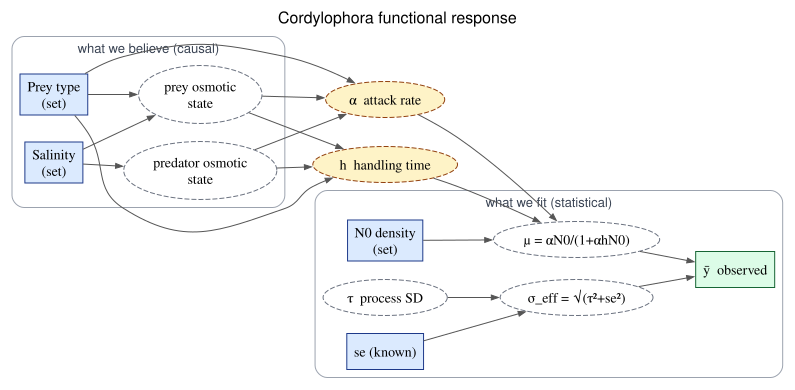

In [7]:
two_panel_dag("M1")   # renders inline; causal + statistical structure of M1

In [8]:
two_panel_dag("M1").render(FIG_DIR/'m1_dag', format="pdf", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m1_dag.pdf'

In [9]:
two_panel_dag("M1").render(FIG_DIR/'m1_dag', format="png", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m1_dag.png'

## Build the model

In [ ]:
fr_model = build_model(
    coords=coords, N0=N0, ybar=ybar, se=se, prey_idx=prey_idx, sal_idx=sal_idx
)

## Structural checks

Confirm the model graph is wired as intended and that the log-probability evaluates
cleanly at the initial point, before spending any sampling time.

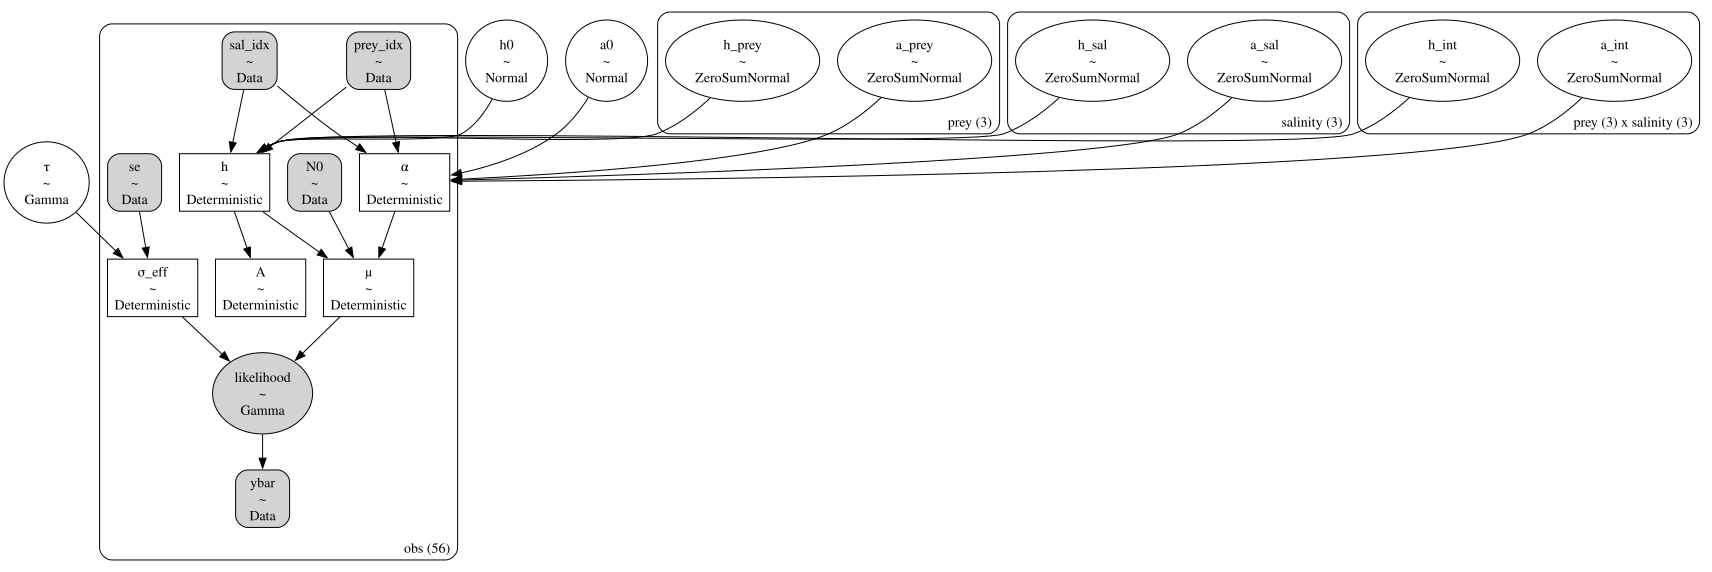

In [11]:
fr_model.to_graphviz()

In [12]:
fr_model.debug()

point={'a0': array(0.), 'a_prey_zerosum__': array([0., 0.]), 'a_sal_zerosum__': array([0., 0.]), 'a_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'h0': array(-3.68887945), 'h_prey_zerosum__': array([0., 0.]), 'h_sal_zerosum__': array([0., 0.]), 'h_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'τ_log__': array(0.98837646)}

No problems found


## Prior predictive check

Simulate from the priors alone (no conditioning on `ybar`) and confirm: (1) simulated
consumption is structurally sane relative to the offered density, and (2) implied
attack rates and asymptotes are biologically plausible.

In [25]:
with fr_model:
    idata = pm.sample_prior_predictive()


Sampling: [a0, a_int, a_prey, a_sal, h0, h_int, h_prey, h_sal, likelihood, τ]


In [17]:
prior_pred_y = idata.prior_predictive["likelihood"]   # (chain, draw, obs)
N0_check = idata.constant_data["N0"]                   # (obs,)

# 1) STRUCTURAL: every simulated consumption must lie in (0, N0).
#    This tests the logit+log construction, not the priors. Must be exactly 0.
over  = (prior_pred_y > N0_check).mean().item()
under = (prior_pred_y < 0).mean().item()
print(f"P(sim > N0) = {over:.4f}   P(sim < 0) = {under:.4f}")

# 2) BIOLOGICAL: implied asymptote A = 1/h should be tens of prey, not millions.
A = idata.prior["A"]
print("A (1/h) quantiles 1/50/99:", np.round(A.quantile([.01,.5,.99]).values, 1))

# while you're here, the attack rate shouldn't pile at the bounds:
a = idata.prior["\u03b1"]
print("\u03b1 quantiles 1/50/99:", np.round(a.quantile([.01,.5,.99]).values, 3))


P(sim > N0) = 0.0312   P(sim < 0) = 0.0000
A (1/h) quantiles 1/50/99: [  4.8  38.3 362.8]
α quantiles 1/50/99: [0.025 0.514 0.983]


/Users/erdemkarakoylu/miniconda3/envs/causal_marine/lib/python3.13/site-packages/arviz_plots/plots/utils_ppc.py:68: UserWarning: This plot always uses the `observed_data` group.
Be cautious when using it for prior predictive checks.
  warn_if_prior_predictive(group)


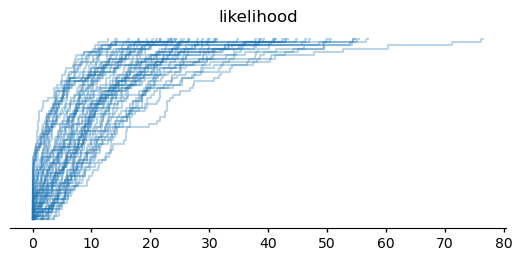

In [18]:
#pp = idata.stack(sample=("chain", "draw"))   # arviz_plots' ppc plot chokes on chain=1; stack first
pc = azp.plot_ppc_dist(idata, group="prior_predictive")

## Sampling

In [28]:
with fr_model:
    idata.update(pm.sample(draws=2000))


/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_40297/1577943726.py:2: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata.update(pm.sample(draws=2000))
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a_prey, a_sal, a_int, h0, h_prey, h_sal, h_int, τ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


## Convergence diagnostics

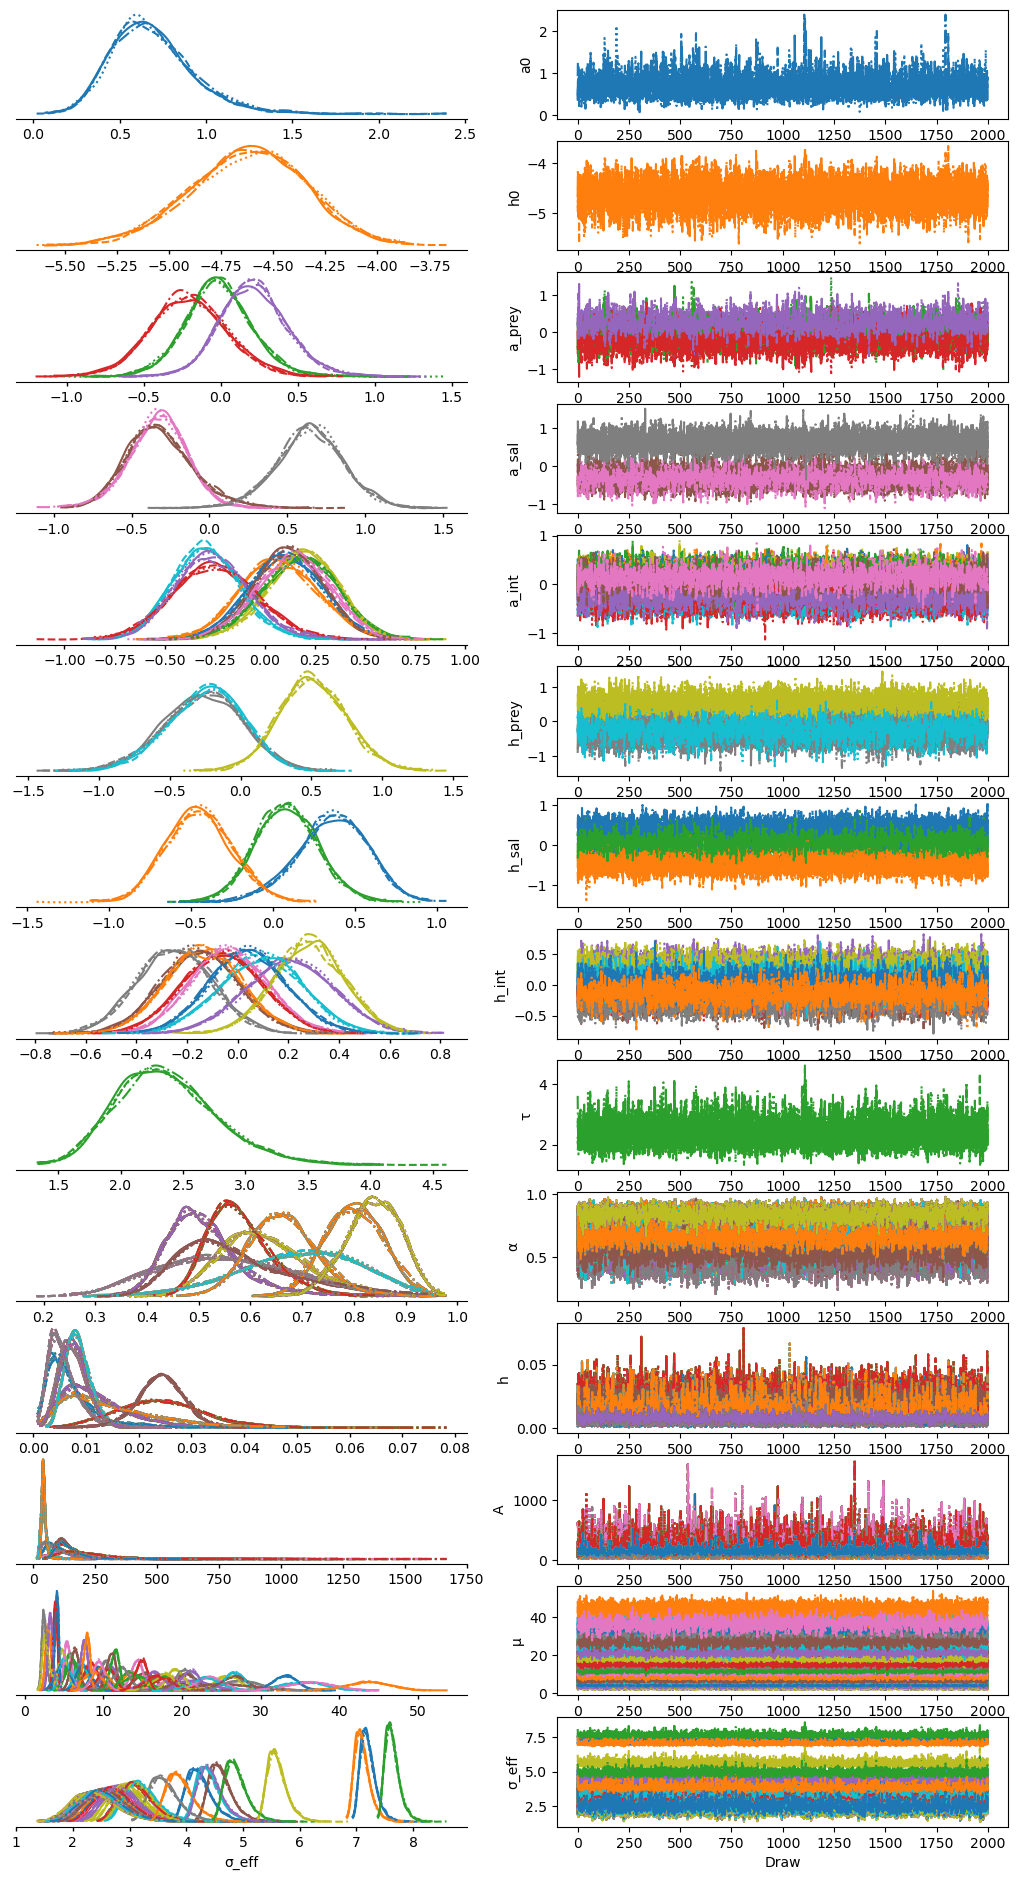

In [15]:
azp.plot_trace_dist(idata)

In [29]:
with fr_model:
    idata.update(pm.sample_posterior_predictive(idata))


Sampling: [likelihood]


Output()

{'coverage': 0.9642857142857143,
 'prob': 0.94,
 'mean_abs_error': 1.9357392450602835,
 'mean_signed_error': 0.2591099528661015}

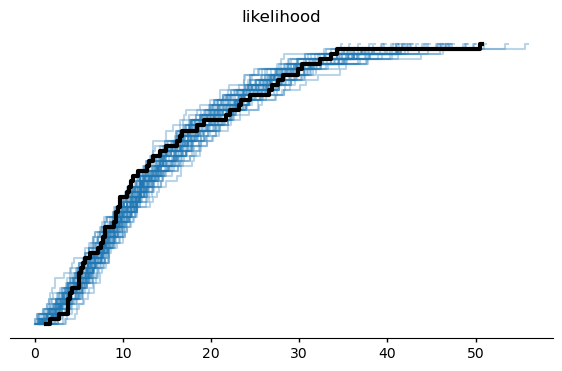

In [59]:
pc = azp.plot_ppc_dist(
    idata, group="posterior_predictive", 
    visuals={"observed_dist": {"linewidth": 3}}, figure_kwargs={"figsize": (7, 4)})
pc.savefig(FIG_DIR / "ppc.png", dpi=300, bbox_inches="tight")

summarize_ppc(idata)

In [29]:
idata.to_netcdf(ART_DIR / 'm1_idata.nc')

In [14]:
idata = xr.open_datatree(ART_DIR / 'm1_idata.nc')

In [15]:
print(idata)                      # sanity check: posterior group, var names, dims
print(list(idata.posterior.data_vars))


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:   (chain: 1, draw: 500, prey: 3, obs: 56, salinity: 3)
│       Coordinates:
│         * chain     (chain) int64 8B 0
│         * draw      (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * prey      (prey) <U4 48B 'Apo' 'Bp' 'Nito'
│         * obs       (obs) int64 448B 0 1 2 3 4 5 6 7 8 ... 47 48 49 50 51 52 53 54 55
│         * salinity  (salinity) int64 24B 10 20 30
│       Data variables: (12/14)
│           a0        (chain, draw) float64 4kB ...
│           h_prey    (chain, draw, prey) float64 12kB ...
│           τ         (chain, draw) float64 4kB ...
│           a_prey    (chain, draw, prey) float64 12kB ...
│           h         (chain, draw, obs) float64 224kB ...
│           A         (chain, draw, obs) float64 224kB ...
│           ...        ...
│           μ         (chain, draw, obs) float64 224kB ...
│           a_int     (chain, draw, prey, salinity) float64 36kB ...
│        

In [19]:
ok, diag = azs.diagnose(idata, return_diagnostics=True, show_diagnostics=False)
print(ok)
print(diag)


False
{'divergent': {'n_divergent': 0, 'pct': np.float64(0.0), 'total_samples': np.int64(8000)}, 'treedepth': {'n_max': 0, 'pct': np.float64(0.0), 'total_samples': np.int64(8000)}, 'bfmi': {'bfmi_values': array([1.01089427, 0.90382353, 0.925724  , 0.8957071 ]), 'failed_chains': [], 'threshold': 0.3}, 'ess': {'bad_params': [], 'ess_values': <xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*, 'threshold_ratio': 0.001, 'total_samples': np.int64(8000)}, 'rhat': {'bad_params': [], 'rhat_values': <xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*, 'threshold': 1.01}}


## Posterior contrasts: confirming/denying Nandini et al.'s claims

1. Copepods eaten more than rotifers
2. Nitokra (harpacticoid) preferred over Apocyclops (cyclopoid)
3. Salinity makes no real difference (over the tested range)
4. Prey and salinity interact.

All reported intervals below are 94% HDIs, read directly (no region-of-practical-
equivalence threshold applied).

In [20]:
attack_rate, handling_time = reconstruct_mechanistic_parameters(idata.posterior)


### Attack rate: pairwise prey contrasts

`expected_eaten` (from `stats_utils`) is available for consumption-at-a-density
questions but is not invoked below; the contrasts here are on attack rate directly.

In [21]:
for p1, p2 in [("Nito","Apo"), ("Nito","Bp"), ("Apo","Bp")]:
    compare(attack_rate.sel(prey=p1).mean("salinity"),
            attack_rate.sel(prey=p2).mean("salinity"),
            f"{p1} vs {p2} (alpha)")


Nito vs Apo (alpha)                      mean=+0.047  94% HDI=[-0.082, +0.175]  P(a>b)=0.77
Nito vs Bp (alpha)                       mean=+0.082  94% HDI=[-0.085, +0.241]  P(a>b)=0.83
Apo vs Bp (alpha)                        mean=+0.035  94% HDI=[-0.132, +0.197]  P(a>b)=0.65


### Attack rate: pairwise salinity contrasts, and forest plot

,mean,hdi_low,hdi_high,p_gt_ref
contrast,,,,
Nito - Apo,0.046894,-0.082318,0.175486,0.770000
Nito - Bp,0.081989,-0.084551,0.240836,0.832375
Apo - Bp,0.035095,-0.132237,0.197287,0.650625
sal 10 - 30,-0.189501,-0.337970,-0.037962,0.015250
sal 10 - 20,0.001277,-0.141614,0.146366,0.482750
sal 20 - 30,-0.190778,-0.304461,-0.069901,0.005000


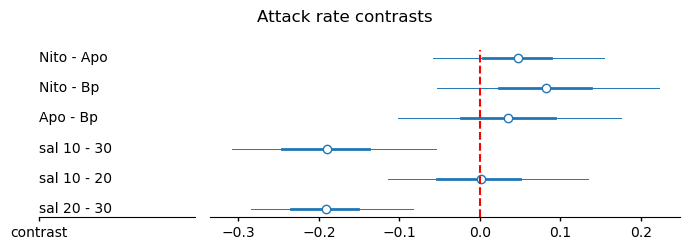

In [57]:
a_pieces = {
    "Nito - Apo":  (attack_rate.sel(prey="Nito") - attack_rate.sel(prey="Apo")).mean("salinity"),
    "Nito - Bp":   (attack_rate.sel(prey="Nito") - attack_rate.sel(prey="Bp")).mean("salinity"),
    "Apo - Bp":    (attack_rate.sel(prey="Apo")  - attack_rate.sel(prey="Bp")).mean("salinity"),
    "sal 10 - 30": (attack_rate.sel(salinity=10) - attack_rate.sel(salinity=30)).mean("prey"),
    "sal 10 - 20": (attack_rate.sel(salinity=10) - attack_rate.sel(salinity=20)).mean("prey"),
    "sal 20 - 30": (attack_rate.sel(salinity=20) - attack_rate.sel(salinity=30)).mean("prey"),
}
a_contrasts = named_contrast_dataset(a_pieces, "\u0394 attack rate")
render_forest(a_contrasts, "\u0394 attack rate", "Attack rate contrasts", ref_line=0.0,
              figsize=(7, 2.5), save_path=FIG_DIR / "forest_attack_rate.png", save_kwargs={"dpi": 300})

summarize_contrasts(a_pieces, ref=0.0)

### Handling time: pairwise prey and salinity contrasts (differences and ratios)

Handling time is modeled multiplicatively (`h = exp(...)`), so raw differences are hard
to read against a small, cell-dependent baseline; both the raw difference and the
fold-change ratio are printed, and the ratio is used for the forest plot.

,mean,hdi_low,hdi_high,p_gt_ref
contrast,,,,
Nito / Apo,1.217479,0.307508,2.365567,0.561500
Nito / Bp,0.556207,0.169466,1.033850,0.058500
Apo / Bp,0.560041,0.143013,1.058515,0.070125
sal 10/30,1.494152,0.566404,2.482275,0.820500
sal 10/20,2.546775,1.033565,4.292468,0.989250
sal 20/30,0.686436,0.293933,1.154848,0.106625


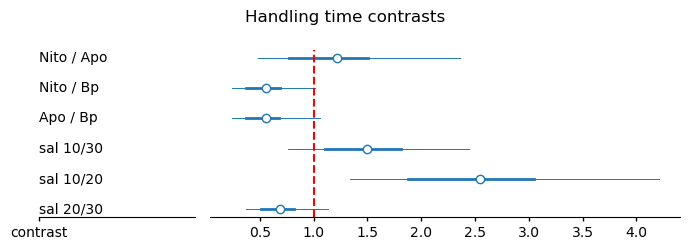

In [56]:
h_pieces = {
    "Nito / Apo": (handling_time.sel(prey="Nito") / handling_time.sel(prey="Apo")).mean("salinity"),
    "Nito / Bp":  (handling_time.sel(prey="Nito") / handling_time.sel(prey="Bp")).mean("salinity"),
    "Apo / Bp":   (handling_time.sel(prey="Apo")  / handling_time.sel(prey="Bp")).mean("salinity"),
    "sal 10/30":  (handling_time.sel(salinity=10) / handling_time.sel(salinity=30)).mean("prey"),
    "sal 10/20":  (handling_time.sel(salinity=10) / handling_time.sel(salinity=20)).mean("prey"),
    "sal 20/30":  (handling_time.sel(salinity=20) / handling_time.sel(salinity=30)).mean("prey"),
}
h_contrasts = named_contrast_dataset(h_pieces, "handling time ratio")
render_forest(h_contrasts, "handling time ratio", "Handling time contrasts", ref_line=1.0,
              figsize=(7, 2.5), save_path=FIG_DIR / "forest_handling_time.png", save_kwargs={"dpi": 300})

summarize_contrasts(h_pieces, ref=1.0)

,prior_mean,prior_sd,post_mean,post_sd,shift_in_prior_sd,sd_ratio
variable,,,,,,
h_prey[Apo],-0.007325,0.413987,-0.271040,0.276565,-0.637014,0.668052
h_prey[Bp],0.002326,0.409890,0.514869,0.237614,1.250443,0.579702
h_prey[Nito],0.004999,0.419435,-0.243829,0.273319,-0.593245,0.651637
h_sal[10],0.002821,0.240137,0.364603,0.214498,1.506563,0.893232
h_sal[20],-0.006091,0.246363,-0.451299,0.196923,-1.807121,0.799321
h_sal[30],0.003270,0.251366,0.086696,0.188785,0.331891,0.751038
"h_int[Apo,10]",-0.004546,0.165036,-0.057669,0.154569,-0.321891,0.936579
"h_int[Apo,20]",0.004325,0.175806,0.206801,0.165530,1.151697,0.941550
"h_int[Apo,30]",0.000220,0.172395,-0.149132,0.152720,-0.866337,0.885872


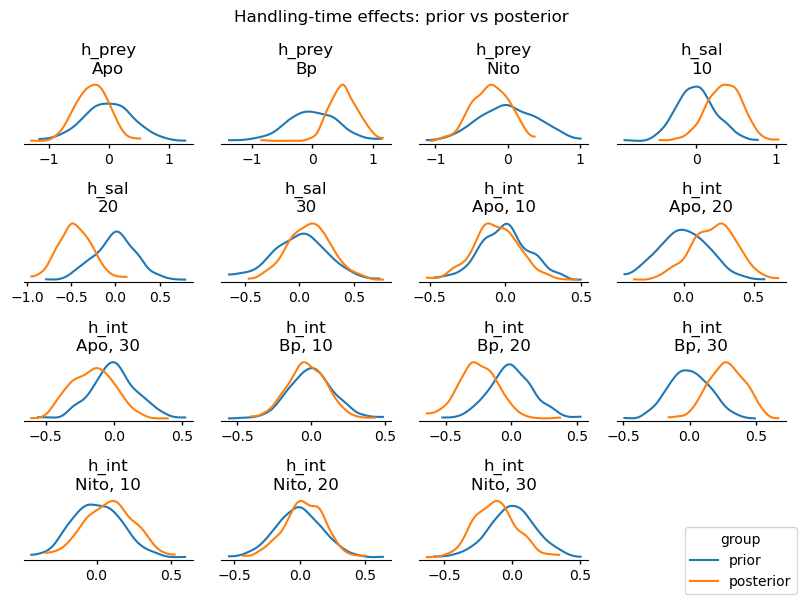

In [58]:
render_prior_posterior(idata, ["h_prey", "h_sal", "h_int"], title="Handling-time effects: prior vs posterior",
                        figsize=(8, 6), legend_loc="lower right",
                        save_path=FIG_DIR / "prior_posterior_h.png", save_kwargs={"dpi": 300})

summarize_prior_posterior(idata, ["h_prey", "h_sal", "h_int"])


## Next steps

- **Reconcile priors.** Re-fit with the maximum-entropy priors from
  `01_prior_elicitation.ipynb` once the handling-time and `tau` elicitation is
  complete, and compare posteriors to confirm the reported contrasts are not
  artifacts of the pre-elicitation prior widths.
- **M2 (bounded-support model).** The prior-predictive check above shows a small but
  nonzero probability of simulated consumption exceeding `N0` -- structurally
  impossible, since the Gamma tail is unbounded even though `mu < N0`. A Beta
  likelihood on the proportion consumed (`ybar/N0`) would respect this bound for the
  observation, not just the mean, at the cost of the clean process/measurement
  variance decomposition M1 provides. Planned as a LOO-CV comparison against M1, not
  yet implemented.

In [ ]:
two_panel_dag("M2")   # preview of the planned bounded-support measurement layer